In [1]:
!pip install -q --upgrade protobuf mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 

In [2]:
!pip uninstall -y mediapipe
!pip install -q mediapipe

# Download the official pose landmarker model
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task -O pose_landmarker.task

print("Model downloaded.")

Found existing installation: mediapipe 1.0.0
Uninstalling mediapipe-1.0.0:
  Successfully uninstalled mediapipe-1.0.0
Model downloaded.


In [3]:
import os
import cv2
import numpy as np
from collections import deque
import json
from datetime import datetime

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision.core.image import Image as MpImage
from mediapipe.tasks.python.vision.core.image import ImageFormat

# -------------------- PATHS --------------------
CALIBRATION_VIDEO = "/kaggle/input/datasets/sarangsharma/balance-axspa/Balance_cal.mp4"
TEST_VIDEO        = "/kaggle/input/datasets/sarangsharma/balance-axspa/balance_1.mp4"
OUTPUT_DIR        = "/kaggle/working/"
MODEL_PATH        = "pose_landmarker.task"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCALE_CM_PER_PIXEL = 0.2292

LEFT_HIP, RIGHT_HIP = 23, 24

def get_hip_center(landmarks, w, h):
    lh = landmarks[LEFT_HIP]
    rh = landmarks[RIGHT_HIP]
    return np.array([(lh.x + rh.x) * 0.5 * w,
                     (lh.y + rh.y) * 0.5 * h], dtype=np.float64)

def create_landmarker():
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.6,
        min_pose_presence_confidence=0.6,
        min_tracking_confidence=0.6
    )
    return vision.PoseLandmarker.create_from_options(options)

def process_calibration(video_path):
    print(f"\n[Calibration] Processing: {os.path.basename(video_path)}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(video_path)

    landmarker = create_landmarker()
    centres = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(frame_idx * 1000 / fps))

        if result.pose_landmarks:
            centres.append(get_hip_center(result.pose_landmarks[0], w, h))
        frame_idx += 1

    cap.release()
    landmarker.close()

    if len(centres) < 10:
        raise RuntimeError("Too few valid detections in calibration video.")

    mean_c = np.mean(np.array(centres), axis=0)
    print(f"[Calibration] Mean centre (px): x={mean_c[0]:.1f}, y={mean_c[1]:.1f} ({len(centres)} frames)")
    return mean_c

def annotate_and_analyse(test_path, mean_center, output_video_path):
    print(f"\n[Test] Processing: {os.path.basename(test_path)}")
    cap = cv2.VideoCapture(test_path)
    if not cap.isOpened():
        raise FileNotFoundError(test_path)

    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    dt     = 1.0 / fps
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    landmarker = create_landmarker()
    trail = deque(maxlen=120)

    prev_x = None
    ml_path_length = 0.0
    max_abs_ml = 0.0
    all_x = []
    velocities = []
    valid_frames = 0
    first_valid_t = last_valid_t = None

    unit = "cm" if SCALE_CM_PER_PIXEL else "px"
    vel_unit = f"{unit}/s"
    scale = SCALE_CM_PER_PIXEL if SCALE_CM_PER_PIXEL else 1.0

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t = frame_idx * dt
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(t * 1000))

        current_ml = 0.0

        if result.pose_landmarks:
            landmarks = result.pose_landmarks[0]
            center = get_hip_center(landmarks, w, h)
            trail.append(center.copy())
            x = center[0]

            ml_px = x - mean_center[0]
            current_ml = ml_px * scale
            abs_ml = abs(current_ml)
            if abs_ml > max_abs_ml:
                max_abs_ml = abs_ml
            all_x.append(x)

            if prev_x is not None:
                dx = (x - prev_x) * scale
                ml_path_length += abs(dx)
                velocities.append(abs(dx) / dt)

            prev_x = x
            valid_frames += 1
            if first_valid_t is None:
                first_valid_t = t
            last_valid_t = t

            # Draw centre + trail
            pts = list(trail)
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                color = (0, int(180 * alpha), int(255 * alpha))
                cv2.line(frame, (int(pts[i-1][0]), int(pts[i-1][1])),
                         (int(pts[i][0]), int(pts[i][1])), color, 2)
            cv2.circle(frame, (int(center[0]), int(center[1])), 8, (0, 255, 255), -1)
            cv2.circle(frame, (int(center[0]), int(center[1])), 12, (0, 200, 255), 2)

        # Live panel
        overlay = frame.copy()
        cv2.rectangle(overlay, (8, 8), (470, 200), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)

        ml_range_now = (max(all_x) - min(all_x)) * scale if all_x else 0.0
        mean_vel = ml_path_length / (last_valid_t - first_valid_t) if (first_valid_t and last_valid_t > first_valid_t) else 0.0
        peak_vel = max(velocities) if velocities else 0.0

        font = cv2.FONT_HERSHEY_SIMPLEX
        y, dy = 38, 26
        cv2.putText(frame, f"ML disp:     {current_ml:+7.1f} {unit}", (20, y), font, 0.65, (0, 255, 255), 2)
        cv2.putText(frame, f"Max ML:      {max_abs_ml:7.1f} {unit}", (20, y+dy), font, 0.65, (0, 255, 120), 2)
        cv2.putText(frame, f"ML range:    {ml_range_now:7.1f} {unit}", (20, y+2*dy), font, 0.65, (255, 200, 50), 2)
        cv2.putText(frame, f"ML path:     {ml_path_length:7.1f} {unit}", (20, y+3*dy), font, 0.65, (255, 160, 50), 2)
        cv2.putText(frame, f"Mean vel:    {mean_vel:7.1f} {vel_unit}", (20, y+4*dy), font, 0.65, (180, 180, 255), 2)
        cv2.putText(frame, f"Peak vel:    {peak_vel:7.1f} {vel_unit}", (20, y+5*dy), font, 0.65, (200, 140, 255), 2)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    landmarker.close()

    duration = (last_valid_t - first_valid_t) if first_valid_t else 0.0
    ml_range = (max(all_x) - min(all_x)) * scale if all_x else 0.0
    mean_vel = ml_path_length / duration if duration > 0 else 0.0
    peak_vel = max(velocities) if velocities else 0.0

    metrics = {
        "max_ml_displacement": round(max_abs_ml, 2),
        "ml_sway_range": round(ml_range, 2),
        "ml_path_length": round(ml_path_length, 2),
        "mean_ml_velocity": round(mean_vel, 2),
        "peak_ml_velocity": round(peak_vel, 2),
        "duration_s": round(duration, 2),
        "valid_frames": valid_frames,
        "unit": unit
    }

    print("\n" + "="*60)
    print("FINAL ML METRICS")
    for k, v in metrics.items():
        print(f"{k:25s}: {v}")
    print("="*60)

    with open(os.path.join(OUTPUT_DIR, "ml_balance_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"Annotated video → {output_video_path}")
    return metrics

# -------------------- RUN --------------------
print("Starting analysis...")
mean_c = process_calibration(CALIBRATION_VIDEO)
output_video = os.path.join(OUTPUT_DIR, "annotated_balance_1.mp4")
metrics = annotate_and_analyse(TEST_VIDEO, mean_c, output_video)
print("\nDone!")

Starting analysis...

[Calibration] Processing: Balance_cal.mp4


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786649028.565957     101 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649028.670820     101 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649028.792965     102 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


[Calibration] Mean centre (px): x=280.0, y=580.1 (316 frames)

[Test] Processing: balance_1.mp4


W0000 00:00:1786649051.838279     117 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649051.944485     117 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



FINAL ML METRICS
max_ml_displacement      : 4.29
ml_sway_range            : 8.57
ml_path_length           : 17.37
mean_ml_velocity         : 0.0
peak_ml_velocity         : 153.71
duration_s               : 0.0
valid_frames             : 917
unit                     : cm
Annotated video → /kaggle/working/annotated_balance_1.mp4

Done!


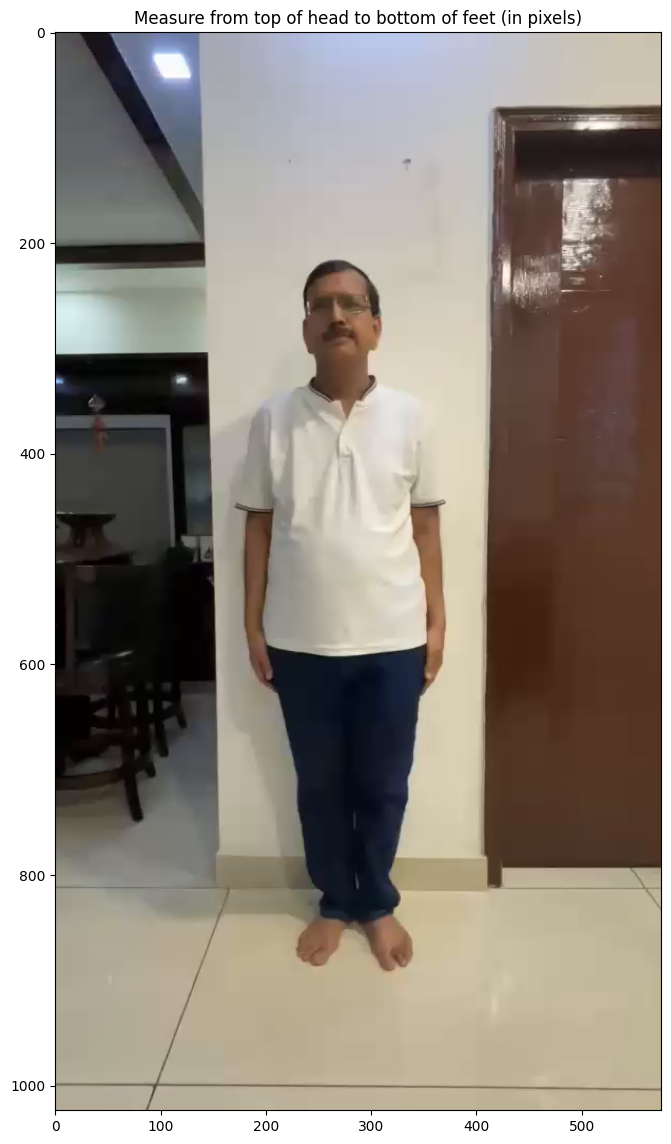

In [4]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/kaggle/input/datasets/sarangsharma/balance-axspa/Balance_cal.mp4")
ret, frame = cap.read()
cap.release()

plt.figure(figsize=(10, 14))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Measure from top of head to bottom of feet (in pixels)")
plt.axis('on')
plt.show()

In [5]:
import os
import cv2
import numpy as np
from collections import deque
import json
from datetime import datetime

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision.core.image import Image as MpImage
from mediapipe.tasks.python.vision.core.image import ImageFormat

# -------------------- PATHS --------------------
CALIBRATION_VIDEO = "/kaggle/input/datasets/sarangsharma/balance-axspa/Balance_cal.mp4"
TEST_VIDEO        = "/kaggle/input/datasets/sarangsharma/balance-axspa/balance_1.mp4"
OUTPUT_DIR        = "/kaggle/working/"
MODEL_PATH        = "pose_landmarker.task"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Scale calculated from height 165 cm ≈ 720 pixels
SCALE_CM_PER_PIXEL = 0.2292

# -------------------- Settings --------------------
LEFT_HIP, RIGHT_HIP = 23, 24
TRAIL_LENGTH = 120

def get_hip_center(landmarks, w, h):
    lh = landmarks[LEFT_HIP]
    rh = landmarks[RIGHT_HIP]
    return np.array([(lh.x + rh.x) * 0.5 * w,
                     (lh.y + rh.y) * 0.5 * h], dtype=np.float64)

def create_landmarker():
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.6,
        min_pose_presence_confidence=0.6,
        min_tracking_confidence=0.6
    )
    return vision.PoseLandmarker.create_from_options(options)

def process_calibration(video_path):
    print(f"\n[Calibration] Processing: {os.path.basename(video_path)}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(video_path)

    landmarker = create_landmarker()
    centres = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(frame_idx * 1000 / fps))

        if result.pose_landmarks:
            centres.append(get_hip_center(result.pose_landmarks[0], w, h))
        frame_idx += 1

    cap.release()
    landmarker.close()

    if len(centres) < 10:
        raise RuntimeError("Too few valid detections in calibration video.")

    mean_c = np.mean(np.array(centres), axis=0)
    print(f"[Calibration] Mean centre (px): x={mean_c[0]:.1f}, y={mean_c[1]:.1f}  ({len(centres)} frames)")
    return mean_c

def annotate_and_analyse(test_path, mean_center, output_video_path):
    print(f"\n[Test] Processing: {os.path.basename(test_path)}")
    cap = cv2.VideoCapture(test_path)
    if not cap.isOpened():
        raise FileNotFoundError(test_path)

    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    dt     = 1.0 / fps
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    landmarker = create_landmarker()
    trail = deque(maxlen=TRAIL_LENGTH)

    prev_x = None
    ml_path_length = 0.0
    max_abs_ml = 0.0
    all_x = []
    velocities = []
    valid_frames = 0

    unit = "cm"
    vel_unit = "cm/s"
    scale = SCALE_CM_PER_PIXEL

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t = frame_idx * dt
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(t * 1000))

        current_ml = 0.0

        if result.pose_landmarks:
            landmarks = result.pose_landmarks[0]
            center = get_hip_center(landmarks, w, h)
            trail.append(center.copy())
            x = center[0]

            ml_px = x - mean_center[0]
            current_ml = ml_px * scale
            abs_ml = abs(current_ml)

            if abs_ml > max_abs_ml:
                max_abs_ml = abs_ml
            all_x.append(x)

            if prev_x is not None:
                dx = (x - prev_x) * scale
                ml_path_length += abs(dx)
                vel = abs(dx) / dt
                velocities.append(vel)

            prev_x = x
            valid_frames += 1

            # Draw trail + centre
            pts = list(trail)
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                color = (0, int(180 * alpha), int(255 * alpha))
                cv2.line(frame,
                         (int(pts[i-1][0]), int(pts[i-1][1])),
                         (int(pts[i][0]), int(pts[i][1])),
                         color, 2)
            cv2.circle(frame, (int(center[0]), int(center[1])), 8, (0, 255, 255), -1)
            cv2.circle(frame, (int(center[0]), int(center[1])), 12, (0, 200, 255), 2)

        # Live metrics panel
        overlay = frame.copy()
        cv2.rectangle(overlay, (8, 8), (460, 195), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)

        ml_range_now = (max(all_x) - min(all_x)) * scale if all_x else 0.0
        duration_so_far = valid_frames / fps if fps > 0 else 0.0
        mean_vel_now = ml_path_length / duration_so_far if duration_so_far > 0 else 0.0
        peak_vel_now = max(velocities) if velocities else 0.0

        font = cv2.FONT_HERSHEY_SIMPLEX
        y0, dy = 38, 26
        cv2.putText(frame, f"ML disp:   {current_ml:+6.1f} {unit}", (20, y0), font, 0.65, (0, 255, 255), 2)
        cv2.putText(frame, f"Max ML:    {max_abs_ml:6.1f} {unit}", (20, y0+dy), font, 0.65, (0, 255, 120), 2)
        cv2.putText(frame, f"ML range:  {ml_range_now:6.1f} {unit}", (20, y0+2*dy), font, 0.65, (255, 200, 50), 2)
        cv2.putText(frame, f"ML path:   {ml_path_length:6.1f} {unit}", (20, y0+3*dy), font, 0.65, (255, 160, 50), 2)
        cv2.putText(frame, f"Mean vel:  {mean_vel_now:6.1f} {vel_unit}", (20, y0+4*dy), font, 0.65, (180, 180, 255), 2)
        cv2.putText(frame, f"Peak vel:  {peak_vel_now:6.1f} {vel_unit}", (20, y0+5*dy), font, 0.65, (200, 140, 255), 2)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    landmarker.close()

    # ---------- Final robust metrics ----------
    duration = valid_frames / fps if (valid_frames > 1 and fps > 0) else 0.0
    ml_range = (max(all_x) - min(all_x)) * scale if all_x else 0.0
    mean_vel = ml_path_length / duration if duration > 0 else 0.0
    peak_vel = max(velocities) if velocities else 0.0

    # Filter unrealistic velocity spikes (common with single-camera tracking)
    filtered_vel = [v for v in velocities if v < 40.0]   # ignore jumps > 40 cm/s
    peak_vel_filtered = max(filtered_vel) if filtered_vel else 0.0

    metrics = {
        "max_ml_displacement_cm": round(max_abs_ml, 2),
        "ml_sway_range_cm": round(ml_range, 2),
        "ml_path_length_cm": round(ml_path_length, 2),
        "mean_ml_velocity_cm_s": round(mean_vel, 2),
        "peak_ml_velocity_cm_s": round(peak_vel, 2),
        "peak_ml_velocity_filtered_cm_s": round(peak_vel_filtered, 2),
        "duration_s": round(duration, 2),
        "valid_frames": valid_frames,
        "unit": "cm"
    }

    print("\n" + "=" * 65)
    print("FINAL ML METRICS")
    print("=" * 65)
    for k, v in metrics.items():
        print(f"{k:40s}: {v}")
    print("=" * 65)

    metrics_path = os.path.join(OUTPUT_DIR, "ml_balance_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"\nMetrics saved  → {metrics_path}")
    print(f"Annotated video → {output_video_path}")
    return metrics

# -------------------- RUN --------------------
print("Starting analysis...")
print(f"Scale = {SCALE_CM_PER_PIXEL:.4f} cm/pixel")

mean_c = process_calibration(CALIBRATION_VIDEO)
output_video = os.path.join(OUTPUT_DIR, "annotated_balance_1.mp4")
metrics = annotate_and_analyse(TEST_VIDEO, mean_c, output_video)

print("\nDone!")

Starting analysis...
Scale = 0.2292 cm/pixel

[Calibration] Processing: Balance_cal.mp4


W0000 00:00:1786649123.876154     142 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649123.975044     141 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[Calibration] Mean centre (px): x=280.0, y=580.1  (316 frames)

[Test] Processing: balance_1.mp4


W0000 00:00:1786649146.886751     155 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649147.009317     156 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



FINAL ML METRICS
max_ml_displacement_cm                  : 4.29
ml_sway_range_cm                        : 8.57
ml_path_length_cm                       : 17.37
mean_ml_velocity_cm_s                   : 0.57
peak_ml_velocity_cm_s                   : 153.71
peak_ml_velocity_filtered_cm_s          : 15.97
duration_s                              : 30.57
valid_frames                            : 917
unit                                    : cm

Metrics saved  → /kaggle/working/ml_balance_metrics.json
Annotated video → /kaggle/working/annotated_balance_1.mp4

Done!


In [6]:
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task -O pose_landmarker.task

import os
print("Model downloaded:" , os.path.exists("pose_landmarker.task"))
print("File size:", round(os.path.getsize("pose_landmarker.task") / 1e6, 1), "MB")

Model downloaded: True
File size: 30.7 MB


In [7]:
!pip install -q mediapipe

import os
import cv2
import numpy as np
from collections import deque
import json
from datetime import datetime

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision.core.image import Image as MpImage
from mediapipe.tasks.python.vision.core.image import ImageFormat

# -------------------- PATHS --------------------
CALIBRATION_VIDEO = "/kaggle/input/datasets/sarangsharma/balance-axspa/Balance_cal.mp4"
TEST_VIDEO        = "/kaggle/input/datasets/sarangsharma/balance-axspa/balance_1.mp4"
OUTPUT_DIR        = "/kaggle/working/"
MODEL_PATH        = "pose_landmarker.task"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Scale (165 cm / ~720 px)
SCALE_CM_PER_PIXEL = 0.2292

# -------------------- Settings --------------------
LEFT_HIP, RIGHT_HIP = 23, 24
LEFT_ANKLE, RIGHT_ANKLE = 27, 28
LEFT_HEEL, RIGHT_HEEL = 29, 30
TRAIL_LENGTH = 120

def get_hip_center(landmarks, w, h):
    lh = landmarks[LEFT_HIP]
    rh = landmarks[RIGHT_HIP]
    return np.array([(lh.x + rh.x) * 0.5 * w,
                     (lh.y + rh.y) * 0.5 * h], dtype=np.float64)

def create_landmarker():
    base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.6,
        min_pose_presence_confidence=0.6,
        min_tracking_confidence=0.6
    )
    return vision.PoseLandmarker.create_from_options(options)

def process_calibration(video_path):
    print(f"\n[Calibration] Processing: {os.path.basename(video_path)}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(video_path)

    landmarker = create_landmarker()
    centres = []
    frame_idx = 0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(frame_idx * 1000 / fps))
        if result.pose_landmarks:
            centres.append(get_hip_center(result.pose_landmarks[0], w, h))
        frame_idx += 1

    cap.release()
    landmarker.close()

    if len(centres) < 10:
        raise RuntimeError("Too few valid detections in calibration video.")
    mean_c = np.mean(np.array(centres), axis=0)
    print(f"[Calibration] Mean centre (px): x={mean_c[0]:.1f}, y={mean_c[1]:.1f}")
    return mean_c

def analyse_with_segmentation(test_path, mean_center, output_video_path):
    print(f"\n[Test + Segmentation] Processing: {os.path.basename(test_path)}")
    cap = cv2.VideoCapture(test_path)
    if not cap.isOpened():
        raise FileNotFoundError(test_path)

    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    dt     = 1.0 / fps
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    landmarker = create_landmarker()
    trail = deque(maxlen=TRAIL_LENGTH)

    # Storage for full trial + per-frame data
    all_x = []
    all_ml = []
    all_times = []
    all_stance = []          # 2 = double, 1 = single
    velocities = []
    prev_x = None
    ml_path_length = 0.0
    max_abs_ml = 0.0
    valid_frames = 0

    scale = SCALE_CM_PER_PIXEL
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t = frame_idx * dt
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(t * 1000))

        current_ml = 0.0
        stance_label = 2   # default double

        if result.pose_landmarks:
            lm = result.pose_landmarks[0]
            center = get_hip_center(lm, w, h)
            trail.append(center.copy())
            x = center[0]

            ml_px = x - mean_center[0]
            current_ml = ml_px * scale
            abs_ml = abs(current_ml)

            if abs_ml > max_abs_ml:
                max_abs_ml = abs_ml
            all_x.append(x)
            all_ml.append(current_ml)
            all_times.append(t)

            # Simple foot detection for stance classification
            feet_visible = 0
            for idx in [LEFT_ANKLE, RIGHT_ANKLE, LEFT_HEEL, RIGHT_HEEL]:
                if lm[idx].visibility > 0.55:
                    feet_visible += 0.5
            stance_label = 2 if feet_visible >= 1.5 else 1
            all_stance.append(stance_label)

            if prev_x is not None:
                dx = (x - prev_x) * scale
                ml_path_length += abs(dx)
                vel = abs(dx) / dt
                velocities.append(vel)
            prev_x = x
            valid_frames += 1

            # Draw trail + centre
            pts = list(trail)
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                color = (0, int(180 * alpha), int(255 * alpha))
                cv2.line(frame, (int(pts[i-1][0]), int(pts[i-1][1])),
                         (int(pts[i][0]), int(pts[i][1])), color, 2)
            cv2.circle(frame, (int(center[0]), int(center[1])), 8, (0, 255, 255), -1)

        # Live overlay
        overlay = frame.copy()
        cv2.rectangle(overlay, (8, 8), (470, 210), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)

        ml_range_now = (max(all_x) - min(all_x)) * scale if all_x else 0.0
        duration_so_far = valid_frames / fps if fps > 0 else 0.0
        mean_vel_now = ml_path_length / duration_so_far if duration_so_far > 0 else 0.0
        peak_vel_now = max(velocities) if velocities else 0.0

        font = cv2.FONT_HERSHEY_SIMPLEX
        y0, dy = 35, 26
        cv2.putText(frame, f"ML disp:   {current_ml:+6.1f} cm", (20, y0), font, 0.65, (0, 255, 255), 2)
        cv2.putText(frame, f"Max ML:    {max_abs_ml:6.1f} cm", (20, y0+dy), font, 0.65, (0, 255, 120), 2)
        cv2.putText(frame, f"ML range:  {ml_range_now:6.1f} cm", (20, y0+2*dy), font, 0.65, (255, 200, 50), 2)
        cv2.putText(frame, f"ML path:   {ml_path_length:6.1f} cm", (20, y0+3*dy), font, 0.65, (255, 160, 50), 2)
        cv2.putText(frame, f"Mean vel:  {mean_vel_now:6.1f} cm/s", (20, y0+4*dy), font, 0.65, (180, 180, 255), 2)
        cv2.putText(frame, f"Peak vel:  {peak_vel_now:6.1f} cm/s", (20, y0+5*dy), font, 0.65, (200, 140, 255), 2)

        # Show current stance label
        stance_txt = "Double" if stance_label == 2 else "Single"
        cv2.putText(frame, f"Stance: {stance_txt}", (20, y0+6*dy+5), font, 0.65, (0, 220, 255), 2)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    landmarker.close()

    # -------------------- Segmentation --------------------
   # -------------------- REPLACE the segmentation part with this --------------------

def analyse_with_segmentation(test_path, mean_center, output_video_path):
    print(f"\n[Test + Segmentation] Processing: {os.path.basename(test_path)}")
    cap = cv2.VideoCapture(test_path)
    if not cap.isOpened():
        raise FileNotFoundError(test_path)

    fps    = cap.get(cv2.CAP_PROP_FPS) or 30.0
    dt     = 1.0 / fps
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    landmarker = create_landmarker()
    trail = deque(maxlen=TRAIL_LENGTH)

    all_x, all_ml, all_times = [], [], []
    velocities = []
    prev_x = None
    ml_path_length = 0.0
    max_abs_ml = 0.0
    valid_frames = 0
    scale = SCALE_CM_PER_PIXEL
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t = frame_idx * dt
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = MpImage(image_format=ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_image, int(t * 1000))

        current_ml = 0.0

        if result.pose_landmarks:
            lm = result.pose_landmarks[0]
            center = get_hip_center(lm, w, h)
            trail.append(center.copy())
            x = center[0]

            ml_px = x - mean_center[0]
            current_ml = ml_px * scale
            abs_ml = abs(current_ml)

            if abs_ml > max_abs_ml:
                max_abs_ml = abs_ml

            all_x.append(x)
            all_ml.append(current_ml)
            all_times.append(t)

            if prev_x is not None:
                dx = (x - prev_x) * scale
                ml_path_length += abs(dx)
                velocities.append(abs(dx) / dt)
            prev_x = x
            valid_frames += 1

            # Draw trail + centre
            pts = list(trail)
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                color = (0, int(180 * alpha), int(255 * alpha))
                cv2.line(frame, (int(pts[i-1][0]), int(pts[i-1][1])),
                         (int(pts[i][0]), int(pts[i][1])), color, 2)
            cv2.circle(frame, (int(center[0]), int(center[1])), 8, (0, 255, 255), -1)

        # Live overlay
        overlay = frame.copy()
        cv2.rectangle(overlay, (8, 8), (470, 195), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.55, frame, 0.45, 0, frame)

        ml_range_now = (max(all_x) - min(all_x)) * scale if all_x else 0.0
        duration_so_far = valid_frames / fps if fps > 0 else 0.0
        mean_vel_now = ml_path_length / duration_so_far if duration_so_far > 0 else 0.0
        peak_vel_now = max(velocities) if velocities else 0.0

        font = cv2.FONT_HERSHEY_SIMPLEX
        y0, dy = 35, 26
        cv2.putText(frame, f"ML disp:   {current_ml:+6.1f} cm", (20, y0), font, 0.65, (0, 255, 255), 2)
        cv2.putText(frame, f"Max ML:    {max_abs_ml:6.1f} cm", (20, y0+dy), font, 0.65, (0, 255, 120), 2)
        cv2.putText(frame, f"ML range:  {ml_range_now:6.1f} cm", (20, y0+2*dy), font, 0.65, (255, 200, 50), 2)
        cv2.putText(frame, f"ML path:   {ml_path_length:6.1f} cm", (20, y0+3*dy), font, 0.65, (255, 160, 50), 2)
        cv2.putText(frame, f"Mean vel:  {mean_vel_now:6.1f} cm/s", (20, y0+4*dy), font, 0.65, (180, 180, 255), 2)
        cv2.putText(frame, f"Peak vel:  {peak_vel_now:6.1f} cm/s", (20, y0+5*dy), font, 0.65, (200, 140, 255), 2)

        # Time-based stance label (most reliable for your protocol)
        if t < 10.0:
            stance_txt = "Initial_Position"
        elif t < 20.0:
            stance_txt = "Semi_tandem"
        else:
            stance_txt = "Full_tandem"
        cv2.putText(frame, f"Stance: {stance_txt}", (20, y0+6*dy+5), font, 0.65, (0, 220, 255), 2)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    landmarker.close()

    # -------------------- Reliable time-based segmentation --------------------
    # Because recording was paused between stances, we use fixed 10-second windows
    total_duration = all_times[-1] if all_times else 0.0

    stance_windows = [
        {"name": "Initial_Position",   "start": 0.0,  "end": 10.0},
        {"name": "Semi_tandem", "start": 10.0, "end": 20.0},
        {"name": "Full_tandem", "start": 20.0, "end": total_duration + 0.1}
    ]

    segments = []
    for win in stance_windows:
        # Find frames belonging to this window
        idxs = [i for i, t in enumerate(all_times) if win["start"] <= t < win["end"]]
        if len(idxs) < 10:
            continue

        seg_ml = [all_ml[i] for i in idxs]
        seg_x  = [all_x[i] for i in idxs]
        start_t = all_times[idxs[0]]
        end_t   = all_times[idxs[-1]]
        duration = end_t - start_t

        max_ml = max(abs(m) for m in seg_ml)
        range_ml = (max(seg_x) - min(seg_x)) * scale
        path = sum(abs(seg_x[j] - seg_x[j-1]) for j in range(1, len(seg_x))) * scale
        mean_v = path / duration if duration > 0 else 0.0

        segments.append({
            "stance": win["name"],
            "start_s": round(start_t, 2),
            "end_s": round(end_t, 2),
            "duration_s": round(duration, 2),
            "max_ml_cm": round(max_ml, 2),
            "ml_range_cm": round(range_ml, 2),
            "ml_path_cm": round(path, 2),
            "mean_vel_cm_s": round(mean_v, 2)
        })

    # Overall metrics
    duration = valid_frames / fps if valid_frames > 1 else 0.0
    ml_range = (max(all_x) - min(all_x)) * scale if all_x else 0.0
    mean_vel = ml_path_length / duration if duration > 0 else 0.0
    peak_vel = max(velocities) if velocities else 0.0
    filtered_vel = [v for v in velocities if v < 40.0]
    peak_vel_f = max(filtered_vel) if filtered_vel else 0.0

    metrics = {
        "overall": {
            "max_ml_displacement_cm": round(max_abs_ml, 2),
            "ml_sway_range_cm": round(ml_range, 2),
            "ml_path_length_cm": round(ml_path_length, 2),
            "mean_ml_velocity_cm_s": round(mean_vel, 2),
            "peak_ml_velocity_cm_s": round(peak_vel, 2),
            "peak_ml_velocity_filtered_cm_s": round(peak_vel_f, 2),
            "duration_s": round(duration, 2),
            "valid_frames": valid_frames
        },
        "stances": segments
    }

    # Print
    print("\n" + "="*70)
    print("OVERALL ML METRICS")
    print("="*70)
    for k, v in metrics["overall"].items():
        print(f"{k:40s}: {v}")

    print("\n" + "="*70)
    print("PER-STANCE METRICS (10-second windows)")
    print("="*70)
    for i, seg in enumerate(segments, 1):
        print(f"\nStance {i}: {seg['stance']}")
        print(f"  Time        : {seg['start_s']:.2f}s → {seg['end_s']:.2f}s  ({seg['duration_s']:.2f}s)")
        print(f"  Max ML      : {seg['max_ml_cm']:.2f} cm")
        print(f"  ML Range    : {seg['ml_range_cm']:.2f} cm")
        print(f"  Path length : {seg['ml_path_cm']:.2f} cm")
        print(f"  Mean vel    : {seg['mean_vel_cm_s']:.2f} cm/s")

    metrics_path = os.path.join(OUTPUT_DIR, "ml_balance_metrics_segmented.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"\nMetrics saved  → {metrics_path}")
    print(f"Annotated video → {output_video_path}")
    return metrics

# -------------------- RUN --------------------
print("Starting full analysis with stance segmentation...")
print(f"Scale = {SCALE_CM_PER_PIXEL:.4f} cm/pixel")

mean_c = process_calibration(CALIBRATION_VIDEO)
output_video = os.path.join(OUTPUT_DIR, "annotated_balance_1_segmented.mp4")
metrics = analyse_with_segmentation(TEST_VIDEO, mean_c, output_video)

print("\nDone!")

Starting full analysis with stance segmentation...
Scale = 0.2292 cm/pixel

[Calibration] Processing: Balance_cal.mp4


W0000 00:00:1786649223.032205     176 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649223.118068     177 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[Calibration] Mean centre (px): x=280.0, y=580.1

[Test + Segmentation] Processing: balance_1.mp4


W0000 00:00:1786649245.478577     189 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649245.560500     191 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



OVERALL ML METRICS
max_ml_displacement_cm                  : 4.29
ml_sway_range_cm                        : 8.57
ml_path_length_cm                       : 17.37
mean_ml_velocity_cm_s                   : 0.57
peak_ml_velocity_cm_s                   : 153.71
peak_ml_velocity_filtered_cm_s          : 15.97
duration_s                              : 30.57
valid_frames                            : 917

PER-STANCE METRICS (10-second windows)

Stance 1: Initial_Position
  Time        : 0.00s → 9.97s  (9.97s)
  Max ML      : 1.66 cm
  ML Range    : 0.67 cm
  Path length : 2.05 cm
  Mean vel    : 0.21 cm/s

Stance 2: Semi_tandem
  Time        : 10.00s → 19.97s  (9.97s)
  Max ML      : 4.28 cm
  ML Range    : 2.93 cm
  Path length : 4.47 cm
  Mean vel    : 0.45 cm/s

Stance 3: Full_tandem
  Time        : 20.00s → 30.53s  (10.53s)
  Max ML      : 4.29 cm
  ML Range    : 7.90 cm
  Path length : 10.83 cm
  Mean vel    : 1.03 cm/s

Metrics saved  → /kaggle/working/ml_balance_metrics_segmented.json
A

In [8]:
# ============================================================
# Stand-and-Reach Test – Final Version with Clean Dashboard
# Right × 2 → Left × 2
# Clean video overlay + Professional results table
# ============================================================

!pip install -q mediapipe opencv-python scipy pandas

import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks
from pathlib import Path
import urllib.request
import os

# ----------------------------- USER CONFIG -----------------------------
VIDEO_PATH = "/kaggle/input/datasets/sarangsharma/stand-and-reach/Reach.mp4"
SUBJECT_HEIGHT_CM = 165.0

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_VIDEO = OUTPUT_DIR / "stand_reach_FINAL_annotated.mp4"
OUTPUT_CSV   = OUTPUT_DIR / "stand_reach_FINAL_metrics.csv"
# -----------------------------------------------------------------------

MODEL_URL  = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task"
MODEL_PATH = "/kaggle/working/pose_landmarker_lite.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading Pose Landmarker model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

BaseOptions = python.BaseOptions
PoseLandmarker = vision.PoseLandmarker
PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

def elevation_angle(shoulder, elbow, mid_hip, mid_sh):
    torso = mid_hip - mid_sh
    arm   = elbow - shoulder
    torso = torso / (np.linalg.norm(torso) + 1e-8)
    arm   = arm   / (np.linalg.norm(arm)   + 1e-8)
    cosang = np.clip(np.dot(torso, arm), -1.0, 1.0)
    return np.degrees(np.arccos(cosang))

def get_px(lm, w, h):
    return np.array([lm.x * w, lm.y * h])

def process_video(video_path, height_cm):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Video: {w}×{h} @ {fps:.1f} fps\n")

    times, L_flex, R_flex, L_reach, R_reach = [], [], [], [], []

    with PoseLandmarker.create_from_options(options) as landmarker:
        idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            ts = int(idx * 1000 / fps)
            res = landmarker.detect_for_video(mp_img, ts)

            t = idx / fps
            lf = rf = lr = rr = np.nan

            if res.pose_landmarks:
                lms = res.pose_landmarks[0]

                nose  = get_px(lms[0],  w, h)
                l_sh  = get_px(lms[11], w, h)
                r_sh  = get_px(lms[12], w, h)
                l_el  = get_px(lms[13], w, h)
                r_el  = get_px(lms[14], w, h)
                l_wr  = get_px(lms[15], w, h)
                r_wr  = get_px(lms[16], w, h)
                l_hip = get_px(lms[23], w, h)
                r_hip = get_px(lms[24], w, h)
                l_ank = get_px(lms[27], w, h)
                r_ank = get_px(lms[28], w, h)

                mid_sh  = (l_sh + r_sh) / 2
                mid_hip = (l_hip + r_hip) / 2
                mid_ank = (l_ank + r_ank) / 2

                head_top_y = nose[1] - 0.08 * abs(mid_ank[1] - nose[1])
                body_px = abs(mid_ank[1] - head_top_y)
                scale = height_cm / body_px if body_px > 50 else np.nan

                lf = elevation_angle(l_sh, l_el, mid_hip, mid_sh)
                rf = elevation_angle(r_sh, r_el, mid_hip, mid_sh)

                if not np.isnan(scale):
                    lr = (mid_ank[1] - l_wr[1]) * scale
                    rr = (mid_ank[1] - r_wr[1]) * scale

            times.append(t)
            L_flex.append(lf)
            R_flex.append(rf)
            L_reach.append(lr)
            R_reach.append(rr)
            idx += 1

    cap.release()

    times   = np.asarray(times)
    L_flex  = np.asarray(L_flex,  dtype=float)
    R_flex  = np.asarray(R_flex,  dtype=float)
    L_reach = np.asarray(L_reach, dtype=float)
    R_reach = np.asarray(R_reach, dtype=float)

    def fill(a):
        n = np.isnan(a)
        if n.any() and (~n).any():
            a[n] = np.interp(np.flatnonzero(n), np.flatnonzero(~n), a[~n])
        return a

    L_flex  = fill(L_flex)
    R_flex  = fill(R_flex)
    L_reach = fill(L_reach)
    R_reach = fill(R_reach)

    win = max(5, int(0.30 * fps) | 1)
    L_flex_s  = savgol_filter(L_flex,  win, 2)
    R_flex_s  = savgol_filter(R_flex,  win, 2)
    L_reach_s = savgol_filter(L_reach, win, 2)
    R_reach_s = savgol_filter(R_reach, win, 2)

    def make_relative(reach):
        baseline = np.nanpercentile(reach, 12)
        return np.maximum(reach - baseline, 0)

    L_reach_rel = make_relative(L_reach_s)
    R_reach_rel = make_relative(R_reach_s)

    # -------------------- Peak Detection --------------------
    min_dist = int(0.9 * fps)

    def find_top2_raises(flex_signal, reach_signal):
        peaks, props = find_peaks(
            flex_signal,
            height=55,
            distance=min_dist,
            prominence=12
        )
        if len(peaks) == 0:
            return []
        scores = flex_signal[peaks] + 0.25 * reach_signal[peaks]
        order = np.argsort(scores)[::-1][:2]
        selected = sorted(peaks[order])
        return selected

    right_peaks = find_top2_raises(R_flex_s, R_reach_rel)
    left_peaks  = find_top2_raises(L_flex_s, L_reach_rel)

    all_events = []
    for i, p in enumerate(right_peaks):
        all_events.append(("right", p, f"Right_T{i+1}"))
    for i, p in enumerate(left_peaks):
        all_events.append(("left",  p, f"Left_T{i+1}"))
    all_events.sort(key=lambda x: x[1])

    half = int(1.0 * fps)
    summary = []

    for side, peak_idx, label in all_events:
        s = max(0, peak_idx - half)
        e = min(len(times) - 1, peak_idx + half)

        if side == "right":
            flex_seg  = R_flex_s[s:e+1]
            reach_seg = R_reach_rel[s:e+1]
        else:
            flex_seg  = L_flex_s[s:e+1]
            reach_seg = L_reach_rel[s:e+1]

        peak_flex  = round(float(np.nanmax(flex_seg)), 1)
        peak_reach = round(float(np.nanmax(reach_seg)), 1)

        # Simple quality status
        status = "Good" if peak_flex >= 150 else "Fair"

        summary.append({
            "Trial": label,
            "Time": f"{times[peak_idx]:.2f} s",
            "Peak Flexion": f"{peak_flex}°",
            "Peak Reach (relative)": f"{peak_reach} cm",
            "Status": status
        })

    summary_df = pd.DataFrame(summary)

    # -------------------- Professional Dashboard --------------------
    print("=" * 72)
    print("               STAND-AND-REACH TEST – RESULTS DASHBOARD")
    print("=" * 72)
    print(f"{'Trial':<12} {'Time':<10} {'Peak Flexion':<16} {'Peak Reach (relative)':<22} {'Status'}")
    print("-" * 72)
    for r in summary:
        print(f"{r['Trial']:<12} {r['Time']:<10} {r['Peak Flexion']:<16} {r['Peak Reach (relative)']:<22} {r['Status']}")
    print("=" * 72)
    print()

    # -------------------- CSV --------------------
    df = pd.DataFrame({
        "frame": np.arange(len(times)),
        "time_s": np.round(times, 3),
        "left_flexion_deg":  np.round(L_flex_s, 1),
        "right_flexion_deg": np.round(R_flex_s, 1),
        "left_reach_cm":  np.round(L_reach_rel, 1),
        "right_reach_cm": np.round(R_reach_rel, 1)
    })

    with open(OUTPUT_CSV, "w") as f:
        f.write("# Per-frame data\n")
        f.write("# Units: flexion = deg, reach = cm (relative to resting position)\n")
    df.to_csv(OUTPUT_CSV, mode="a", index=False)

    with open(OUTPUT_CSV, "a") as f:
        f.write("\n# Summary of detected trials\n")
    summary_df.to_csv(OUTPUT_CSV, mode="a", index=False)

    print(f"CSV saved → {OUTPUT_CSV}")

    # -------------------- Clean Annotated Video --------------------
    cap = cv2.VideoCapture(str(video_path))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps, (w, h))

    with PoseLandmarker.create_from_options(options) as landmarker:
        idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            res = landmarker.detect_for_video(mp_img, int(idx * 1000 / fps))

            if res.pose_landmarks:
                for i in [0, 11, 12, 13, 14, 15, 16, 23, 24, 27, 28]:
                    x = int(res.pose_landmarks[0][i].x * w)
                    y = int(res.pose_landmarks[0][i].y * h)
                    cv2.circle(frame, (x, y), 5, (0, 255, 0), -1)

            overlay = frame.copy()
            cv2.rectangle(overlay, (8, 8), (510, 95), (15, 15, 15), -1)
            cv2.addWeighted(overlay, 0.65, frame, 0.35, 0, frame)

            left_val  = L_flex_s[idx]
            right_val = R_flex_s[idx]

            if right_val >= left_val and right_val > 45:
                text = f"RIGHT  Flex: {R_flex_s[idx]:5.1f} deg    Reach: {R_reach_rel[idx]:5.1f} cm"
                color = (0, 255, 120)
            elif left_val > right_val and left_val > 45:
                text = f"LEFT   Flex: {L_flex_s[idx]:5.1f} deg    Reach: {L_reach_rel[idx]:5.1f} cm"
                color = (0, 255, 255)
            else:
                text = "Arms down   Flex ≈ 0 deg    Reach ≈ 0 cm"
                color = (170, 170, 170)

            cv2.putText(frame, text, (18, 55),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.72, color, 2)

            out.write(frame)
            idx += 1

    cap.release()
    out.release()
    print(f"Annotated video saved → {OUTPUT_VIDEO}\n")

    return summary_df

# ===================== RUN =====================
summary = process_video(VIDEO_PATH, SUBJECT_HEIGHT_CM)

Video: 576×1024 @ 30.0 fps



W0000 00:00:1786649319.731628     210 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649319.759633     208 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


               STAND-AND-REACH TEST – RESULTS DASHBOARD
Trial        Time       Peak Flexion     Peak Reach (relative)  Status
------------------------------------------------------------------------
Right_T1     1.00 s     161.9°           130.8 cm               Good
Right_T2     2.13 s     165.7°           133.1 cm               Good
Left_T1      3.60 s     166.8°           129.8 cm               Good
Left_T2      5.00 s     173.7°           131.2 cm               Good

CSV saved → /kaggle/working/stand_reach_FINAL_metrics.csv


W0000 00:00:1786649323.901237     222 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649323.937525     222 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Annotated video saved → /kaggle/working/stand_reach_FINAL_annotated.mp4



In [9]:
# ============================================================
# Put-on-Socks Test – 4 DISTINCT TRIALS
# Fixed: degree unit display + correct hip/knee flexion direction
# ============================================================

!pip install -q mediapipe opencv-python-headless pandas matplotlib scipy

import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
from pathlib import Path
import urllib.request

# ------------------------------
# 1. CONFIGURATION
# ------------------------------
VIDEO_PATH = "/kaggle/input/datasets/sarangsharma/socks-put/putonsocks.mp4"
OUTPUT_DIR = "/kaggle/working/socks_results"
OUTPUT_VIDEO = os.path.join(OUTPUT_DIR, "put_on_socks_annotated.mp4")
OUTPUT_CSV   = os.path.join(OUTPUT_DIR, "put_on_socks_metrics.csv")
DASHBOARD_PNG = os.path.join(OUTPUT_DIR, "results_dashboard.png")
MODEL_PATH = "/kaggle/working/pose_landmarker_full.task"

EMA_ALPHA = 0.25
MIN_VISIBILITY = 0.5

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------
# 2. TRIAL WINDOWS (your observed start frames)
# ------------------------------
TRIAL_STARTS = {
    1: 324,   # Right Rep 1
    2: 502,   # Right Rep 2
    3: 649,   # Left  Rep 1
    4: 779,   # Left  Rep 2
}
TRIAL_LABELS = {
    1: "Right - Rep 1",
    2: "Right - Rep 2",
    3: "Left  - Rep 1",
    4: "Left  - Rep 2",
}

# ------------------------------
# 3. DOWNLOAD MODEL
# ------------------------------
if not os.path.exists(MODEL_PATH):
    print("Downloading Pose Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Model downloaded.")

# ------------------------------
# 4. DRAWING (pure OpenCV)
# ------------------------------
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    (11, 12), (11, 23), (12, 24), (23, 24),
    (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
    (23, 25), (25, 27), (27, 29), (27, 31), (29, 31),
    (24, 26), (26, 28), (28, 30), (28, 32), (30, 32),
]

def draw_pose(image_bgr, landmarks, w, h,
              connection_color=(0, 255, 0), landmark_color=(0, 0, 255),
              thickness=2, radius=3):
    for s, e in POSE_CONNECTIONS:
        if s < len(landmarks) and e < len(landmarks):
            lm1, lm2 = landmarks[s], landmarks[e]
            if lm1.visibility > 0.5 and lm2.visibility > 0.5:
                pt1 = (int(lm1.x * w), int(lm1.y * h))
                pt2 = (int(lm2.x * w), int(lm2.y * h))
                cv2.line(image_bgr, pt1, pt2, connection_color, thickness, cv2.LINE_AA)
    for lm in landmarks:
        if lm.visibility > 0.5:
            cv2.circle(image_bgr, (int(lm.x * w), int(lm.y * h)),
                       radius, landmark_color, -1, cv2.LINE_AA)

# ------------------------------
# 5. ANGLE HELPERS
# ------------------------------
def joint_angle(a, b, c):
    """Interior angle at b (0-180)."""
    a = np.array(a, dtype=np.float64)
    b = np.array(b, dtype=np.float64)
    c = np.array(c, dtype=np.float64)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def hip_flexion(shoulder, hip, knee):
    """Flexion from full extension. Higher = more flexed.
    Seated ~40 deg, deep forward bend ~150-170 deg."""
    return 180.0 - joint_angle(shoulder, hip, knee)

def knee_flexion(hip, knee, ankle):
    """Flexion from full extension. Higher = more flexed."""
    return 180.0 - joint_angle(hip, knee, ankle)

def trunk_flexion_angle(mid_shoulder, mid_hip):
    """From vertical. 0 = upright, higher = more flexed."""
    vec = np.array(mid_shoulder) - np.array(mid_hip)
    vertical = np.array([0.0, -1.0])
    cos_theta = np.dot(vec, vertical) / (np.linalg.norm(vec) * np.linalg.norm(vertical) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))

def get_xy(landmark, w, h):
    return [landmark.x * w, landmark.y * h], landmark.visibility

class EMASmoother:
    def __init__(self, alpha=0.25):
        self.alpha = alpha
        self.value = None
    def update(self, new_val):
        if new_val is None:
            return self.value
        if self.value is None:
            self.value = new_val
        else:
            self.value = self.alpha * new_val + (1.0 - self.alpha) * self.value
        return self.value

def get_current_trial(frame_idx, starts):
    trial = 0
    for t in sorted(starts.keys()):
        if frame_idx >= starts[t]:
            trial = t
    return trial

# ------------------------------
# 6. LANDMARKER
# ------------------------------
BaseOptions = python.BaseOptions
PoseLandmarker = vision.PoseLandmarker
PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

LS, RS, LH, RH, LK, RK, LA, RA = 11, 12, 23, 24, 25, 26, 27, 28

# ------------------------------
# 7. MAIN PROCESSING
# ------------------------------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

sorted_starts = sorted(TRIAL_STARTS.items())
TRIAL_ENDS = {}
for i, (t, start) in enumerate(sorted_starts):
    if i + 1 < len(sorted_starts):
        TRIAL_ENDS[t] = sorted_starts[i + 1][1] - 1
    else:
        TRIAL_ENDS[t] = total_frames - 1

print("Trial windows (frames):")
for t in range(1, 5):
    print(f"  Trial {t} ({TRIAL_LABELS[t]}): {TRIAL_STARTS[t]} -> {TRIAL_ENDS[t]}  "
          f"({TRIAL_STARTS[t]/fps:.2f}s - {TRIAL_ENDS[t]/fps:.2f}s)")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

records = []
trial_peaks = {t: {"hip": 0.0, "knee": 0.0, "trunk": 0.0} for t in range(1, 5)}

smooth_hip_l  = EMASmoother(EMA_ALPHA)
smooth_hip_r  = EMASmoother(EMA_ALPHA)
smooth_knee_l = EMASmoother(EMA_ALPHA)
smooth_knee_r = EMASmoother(EMA_ALPHA)
smooth_trunk  = EMASmoother(EMA_ALPHA)

with PoseLandmarker.create_from_options(options) as landmarker:
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        timestamp_ms = int(frame_idx * 1000 / fps)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        annotated = frame.copy()
        hip_l = hip_r = knee_l = knee_r = trunk = None
        vis_ok = False
        current_trial = get_current_trial(frame_idx, TRIAL_STARTS)

        if result.pose_landmarks:
            lms = result.pose_landmarks[0]
            draw_pose(annotated, lms, width, height)

            ls, v_ls = get_xy(lms[LS], width, height)
            rs, v_rs = get_xy(lms[RS], width, height)
            lh, v_lh = get_xy(lms[LH], width, height)
            rh, v_rh = get_xy(lms[RH], width, height)
            lk, v_lk = get_xy(lms[LK], width, height)
            rk, v_rk = get_xy(lms[RK], width, height)
            la, v_la = get_xy(lms[LA], width, height)
            ra, v_ra = get_xy(lms[RA], width, height)

            if min(v_ls, v_rs, v_lh, v_rh, v_lk, v_rk) > MIN_VISIBILITY:
                vis_ok = True
                mid_shoulder = [(ls[0] + rs[0]) / 2, (ls[1] + rs[1]) / 2]
                mid_hip      = [(lh[0] + rh[0]) / 2, (lh[1] + rh[1]) / 2]

                # Correct flexion definitions (higher = more flexed)
                hip_l  = hip_flexion(ls, lh, lk)
                hip_r  = hip_flexion(rs, rh, rk)
                knee_l = knee_flexion(lh, lk, la)
                knee_r = knee_flexion(rh, rk, ra)
                trunk  = trunk_flexion_angle(mid_shoulder, mid_hip)

                hip_l  = smooth_hip_l.update(hip_l)
                hip_r  = smooth_hip_r.update(hip_r)
                knee_l = smooth_knee_l.update(knee_l)
                knee_r = smooth_knee_r.update(knee_r)
                trunk  = smooth_trunk.update(trunk)

                if current_trial >= 1:
                    cur_hip  = max(hip_l or 0, hip_r or 0)
                    cur_knee = max(knee_l or 0, knee_r or 0)
                    trial_peaks[current_trial]["hip"]   = max(trial_peaks[current_trial]["hip"],   cur_hip)
                    trial_peaks[current_trial]["knee"]  = max(trial_peaks[current_trial]["knee"],  cur_knee)
                    trial_peaks[current_trial]["trunk"] = max(trial_peaks[current_trial]["trunk"], trunk or 0)

        # ---------- Overlay (ASCII-safe units) ----------
        overlay = annotated.copy()
        cv2.rectangle(overlay, (10, 10), (500, 245), (20, 20, 20), -1)
        cv2.addWeighted(overlay, 0.65, annotated, 0.35, 0, annotated)

        def put(txt, y, color=(240, 240, 240)):
            cv2.putText(annotated, txt, (25, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.58, color, 2, cv2.LINE_AA)

        put(f"Frame: {frame_idx:4d}  |  Time: {frame_idx/fps:5.2f}s", 38)

        trial_txt = TRIAL_LABELS.get(current_trial, "Baseline / Seated")
        put(f"Current: {trial_txt}", 68, (0, 220, 255))

        if hip_l is not None:
            put(f"Hip Flex   L: {hip_l:5.1f} deg   R: {hip_r:5.1f} deg", 100)
            put(f"Knee Flex  L: {knee_l:5.1f} deg   R: {knee_r:5.1f} deg", 130)
            put(f"Trunk Flex     : {trunk:5.1f} deg", 160)
        else:
            put("Hip Flex   --", 100)
            put("Knee Flex  --", 130)
            put("Trunk Flex --", 160)

        if current_trial >= 1:
            p = trial_peaks[current_trial]
            put(f"Trial peaks -> Hip {p['hip']:5.1f}  Knee {p['knee']:5.1f}  Trunk {p['trunk']:5.1f} deg",
                195, (0, 220, 120))
        else:
            put("Trial peaks -> (waiting for first movement)", 195, (180, 180, 180))

        cv2.putText(annotated, "Protocol: 2x Right -> 2x Left (seated put-on-socks)",
                    (15, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 180, 180), 1, cv2.LINE_AA)

        out.write(annotated)

        records.append({
            "frame": frame_idx,
            "time_s": round(frame_idx / fps, 3),
            "trial": current_trial,
            "trial_label": trial_txt,
            "hip_flexion_L": round(hip_l, 2) if hip_l is not None else np.nan,
            "hip_flexion_R": round(hip_r, 2) if hip_r is not None else np.nan,
            "knee_flexion_L": round(knee_l, 2) if knee_l is not None else np.nan,
            "knee_flexion_R": round(knee_r, 2) if knee_r is not None else np.nan,
            "trunk_flexion": round(trunk, 2) if trunk is not None else np.nan,
            "pose_detected": vis_ok
        })

        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"Processed {frame_idx}/{total_frames} frames...")

cap.release()
out.release()
print(f"\nAnnotated video saved -> {OUTPUT_VIDEO}")

# ------------------------------
# 8. CSV + PER-TRIAL SUMMARY
# ------------------------------
df = pd.DataFrame(records)
df.to_csv(OUTPUT_CSV, index=False)
print(f"CSV saved -> {OUTPUT_CSV}")

summary_rows = []
for t in range(1, 5):
    mask = df["trial"] == t
    if mask.any():
        sub = df.loc[mask]
        hip_peak   = float(np.nanmax(sub[["hip_flexion_L", "hip_flexion_R"]].values))
        knee_peak  = float(np.nanmax(sub[["knee_flexion_L", "knee_flexion_R"]].values))
        trunk_peak = float(np.nanmax(sub["trunk_flexion"].values))
        hip_peak   = max(hip_peak,   trial_peaks[t]["hip"])   if not np.isnan(hip_peak)   else trial_peaks[t]["hip"]
        knee_peak  = max(knee_peak,  trial_peaks[t]["knee"])  if not np.isnan(knee_peak)  else trial_peaks[t]["knee"]
        trunk_peak = max(trunk_peak, trial_peaks[t]["trunk"]) if not np.isnan(trunk_peak) else trial_peaks[t]["trunk"]
    else:
        hip_peak = knee_peak = trunk_peak = 0.0

    summary_rows.append({
        "trial": t,
        "label": TRIAL_LABELS[t],
        "start_frame": TRIAL_STARTS[t],
        "end_frame": TRIAL_ENDS[t],
        "start_time_s": round(TRIAL_STARTS[t] / fps, 2),
        "end_time_s": round(TRIAL_ENDS[t] / fps, 2),
        "peak_hip_flexion_deg": round(hip_peak, 1),
        "peak_knee_flexion_deg": round(knee_peak, 1),
        "peak_trunk_flexion_deg": round(trunk_peak, 1),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_peaks_by_trial.csv"), index=False)

# ------------------------------
# 9. DASHBOARD
# ------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 12), facecolor="#f8f9fa")
gs = GridSpec(4, 2, figure=fig, height_ratios=[0.85, 1.0, 1.0, 1.1],
              hspace=0.40, wspace=0.28)

ax0 = fig.add_subplot(gs[0, :])
ax0.axis("off")
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.text(0.5, 0.92, "Put-on-Socks Test  -  Four Distinct Trials",
         ha="center", va="top", fontsize=18, fontweight="bold", color="#1a1a2e")
ax0.text(0.5, 0.68,
         "Hip/Knee flexion = 180 - joint angle (higher = more flexed)  |  Trunk = angle from vertical",
         ha="center", va="top", fontsize=11, color="#444")

colors = ["#e94560", "#0f3460", "#e94560", "#0f3460"]
card_w = 0.20
for i, row in enumerate(summary_rows):
    x = 0.06 + i * 0.24
    ax0.add_patch(plt.Rectangle((x, 0.08), card_w, 0.48, facecolor=colors[i], alpha=0.92))
    ax0.text(x + card_w/2, 0.48, f"Trial {row['trial']}", ha="center", va="center",
             fontsize=11, fontweight="bold", color="white")
    ax0.text(x + card_w/2, 0.36, row["label"], ha="center", va="center",
             fontsize=9, color="white")
    ax0.text(x + card_w/2, 0.20,
             f"Hip {row['peak_hip_flexion_deg']:.0f}  Knee {row['peak_knee_flexion_deg']:.0f}\nTrunk {row['peak_trunk_flexion_deg']:.0f} deg",
             ha="center", va="center", fontsize=9, color="white")

ax1 = fig.add_subplot(gs[1, 0])
ax1.plot(df["time_s"], df["hip_flexion_L"], label="Left", color="#e94560", lw=1.5, alpha=0.8)
ax1.plot(df["time_s"], df["hip_flexion_R"], label="Right", color="#0f3460", lw=1.5, alpha=0.8)
for t in range(1, 5):
    ax1.axvspan(TRIAL_STARTS[t]/fps, TRIAL_ENDS[t]/fps, alpha=0.12, color=colors[t-1])
    ax1.axvline(TRIAL_STARTS[t]/fps, color=colors[t-1], ls="--", lw=1, alpha=0.7)
ax1.set_ylabel("Hip Flexion (deg)")
ax1.set_title("Hip Flexion (shaded = trial windows)", fontweight="bold")
ax1.legend(loc="upper right", fontsize=8)
ax1.set_xlabel("Time (s)")

ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(df["time_s"], df["knee_flexion_L"], label="Left", color="#e94560", lw=1.5, alpha=0.8)
ax2.plot(df["time_s"], df["knee_flexion_R"], label="Right", color="#0f3460", lw=1.5, alpha=0.8)
for t in range(1, 5):
    ax2.axvspan(TRIAL_STARTS[t]/fps, TRIAL_ENDS[t]/fps, alpha=0.12, color=colors[t-1])
    ax2.axvline(TRIAL_STARTS[t]/fps, color=colors[t-1], ls="--", lw=1, alpha=0.7)
ax2.set_ylabel("Knee Flexion (deg)")
ax2.set_title("Knee Flexion (shaded = trial windows)", fontweight="bold")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlabel("Time (s)")

ax3 = fig.add_subplot(gs[2, :])
ax3.plot(df["time_s"], df["trunk_flexion"], color="#16213e", lw=1.8)
for t in range(1, 5):
    ax3.axvspan(TRIAL_STARTS[t]/fps, TRIAL_ENDS[t]/fps, alpha=0.12, color=colors[t-1])
    ax3.axvline(TRIAL_STARTS[t]/fps, color=colors[t-1], ls="--", lw=1.2, alpha=0.8)
ax3.set_ylabel("Trunk Flexion (deg)")
ax3.set_xlabel("Time (s)")
ax3.set_title("Trunk Flexion Angle (from vertical)", fontweight="bold")

ax4 = fig.add_subplot(gs[3, :])
ax4.axis("off")
table_data = [
    [f"Trial {r['trial']}", r["label"],
     f"{r['start_frame']}-{r['end_frame']}",
     f"{r['start_time_s']}-{r['end_time_s']}s",
     f"{r['peak_hip_flexion_deg']:.1f}",
     f"{r['peak_knee_flexion_deg']:.1f}",
     f"{r['peak_trunk_flexion_deg']:.1f}"]
    for r in summary_rows
]
col_labels = ["Trial", "Side / Rep", "Frames", "Time (s)", "Peak Hip", "Peak Knee", "Peak Trunk"]
table = ax4.table(cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1a1a2e")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#f0f0f0" if row % 2 == 0 else "white")

fig.text(0.5, 0.01,
         f"Source: {Path(VIDEO_PATH).name}  |  FPS: {fps:.1f}  |  Frames: {len(df)}  |  "
         f"Hip/Knee = 180 - joint angle  |  Trunk = from vertical",
         ha="center", fontsize=9, color="#666")

plt.savefig(DASHBOARD_PNG, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print(f"Dashboard saved -> {DASHBOARD_PNG}")

# ------------------------------
# 10. CONSOLE
# ------------------------------
print("\n" + "="*70)
print("     PUT-ON-SOCKS TEST - RESULTS BY TRIAL")
print("="*70)
for r in summary_rows:
    print(f"  Trial {r['trial']}  {r['label']:14s}  "
          f"Hip {r['peak_hip_flexion_deg']:5.1f} deg  "
          f"Knee {r['peak_knee_flexion_deg']:5.1f} deg  "
          f"Trunk {r['peak_trunk_flexion_deg']:5.1f} deg  "
          f"[{r['start_frame']}-{r['end_frame']}]")
print("-"*70)
print(f"  Annotated video          : {OUTPUT_VIDEO}")
print(f"  Frame-level CSV          : {OUTPUT_CSV}")
print(f"  Summary by trial CSV     : {os.path.join(OUTPUT_DIR, 'summary_peaks_by_trial.csv')}")
print(f"  Results dashboard        : {DASHBOARD_PNG}")
print("="*70)

Model downloaded.
Trial windows (frames):
  Trial 1 (Right - Rep 1): 324 -> 501  (5.41s - 8.36s)
  Trial 2 (Right - Rep 2): 502 -> 648  (8.38s - 10.81s)
  Trial 3 (Left  - Rep 1): 649 -> 778  (10.83s - 12.98s)
  Trial 4 (Left  - Rep 2): 779 -> 927  (13.00s - 15.47s)


W0000 00:00:1786649332.871583     242 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786649332.916687     243 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processed 30/928 frames...
Processed 60/928 frames...
Processed 90/928 frames...
Processed 120/928 frames...
Processed 150/928 frames...
Processed 180/928 frames...
Processed 210/928 frames...
Processed 240/928 frames...
Processed 270/928 frames...
Processed 300/928 frames...
Processed 330/928 frames...
Processed 360/928 frames...
Processed 390/928 frames...
Processed 420/928 frames...
Processed 450/928 frames...
Processed 480/928 frames...
Processed 510/928 frames...
Processed 540/928 frames...
Processed 570/928 frames...
Processed 600/928 frames...
Processed 630/928 frames...
Processed 660/928 frames...
Processed 690/928 frames...
Processed 720/928 frames...
Processed 750/928 frames...
Processed 780/928 frames...
Processed 810/928 frames...
Processed 840/928 frames...
Processed 870/928 frames...
Processed 900/928 frames...

Annotated video saved -> /kaggle/working/socks_results/put_on_socks_annotated.mp4
CSV saved -> /kaggle/working/socks_results/put_on_socks_metrics.csv
Dashboard sa